In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Install & Import Dependencies

In [2]:
!pip install -q transformers datasets torch accelerate evaluate scikit-learn matplotlib seaborn nlpaug sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 48.2 MB/s eta 0:00:00


In [3]:
import torch
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, TrainingArguments, Trainer, EarlyStoppingCallback, pipeline
import evaluate
import re
from tqdm import tqdm

In [4]:
# Set plot style for clean visualizations
sns.set_theme(style="whitegrid")
%matplotlib inline

# Define your source dataset path
DATASET_PATH = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/data_new.csv"

# Load Data, Remove Duplicates & Text Cleaning

In [5]:
# 1. Load the raw dataset
df_raw = pd.read_csv(DATASET_PATH)
print(f"📊 Initial Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")

# 2. Text Cleaning Function
def clean_utterance(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()                     # Remove leading/trailing whitespaces
    text = re.sub(r'\s+', ' ', text)        # Normalize multi-space gaps to single spaces
    text = text.lower()                     # Convert to lower-case for uniformity
    return text

df_raw['cleaned_text'] = df_raw['text'].apply(clean_utterance)

# 3. Duplicate Identification and Removal
duplicate_mask = df_raw.duplicated(subset=['cleaned_text'], keep=False)
total_duplicates = duplicate_mask.sum()

print(f"🔍 Duplicate Analysis:")
print(f" -> Found {total_duplicates} rows with matching text content.")

if total_duplicates > 0:
    # Retain the first occurrence, drop remaining duplicates
    df_clean = df_raw.drop_duplicates(subset=['cleaned_text'], keep='first').copy()
    print(f" -> ✅ Dropped duplicate records. Clean dataset row count: {len(df_clean)}")
else:
    df_clean = df_raw.copy()
    print(" -> ✅ No strict duplicates detected.")

📊 Initial Dataset Shape: 225 rows, 2 columns

🔍 Duplicate Analysis:
 -> Found 0 rows with matching text content.
 -> ✅ No strict duplicates detected.


# Class Distribution Analysis & Balance Visualization

=== CURRENT INTENT CLASS DISTRIBUTION ===


,Total Samples,Dataset Percentage (%)
label,,
general_question,27,12.00
complaint,25,11.11
logistics,25,11.11
payment,25,11.11
refund,25,11.11
technical_support,25,11.11
self_harm_or_suicide_risk,25,11.11
unknown,25,11.11
product_inquiry,23,10.22


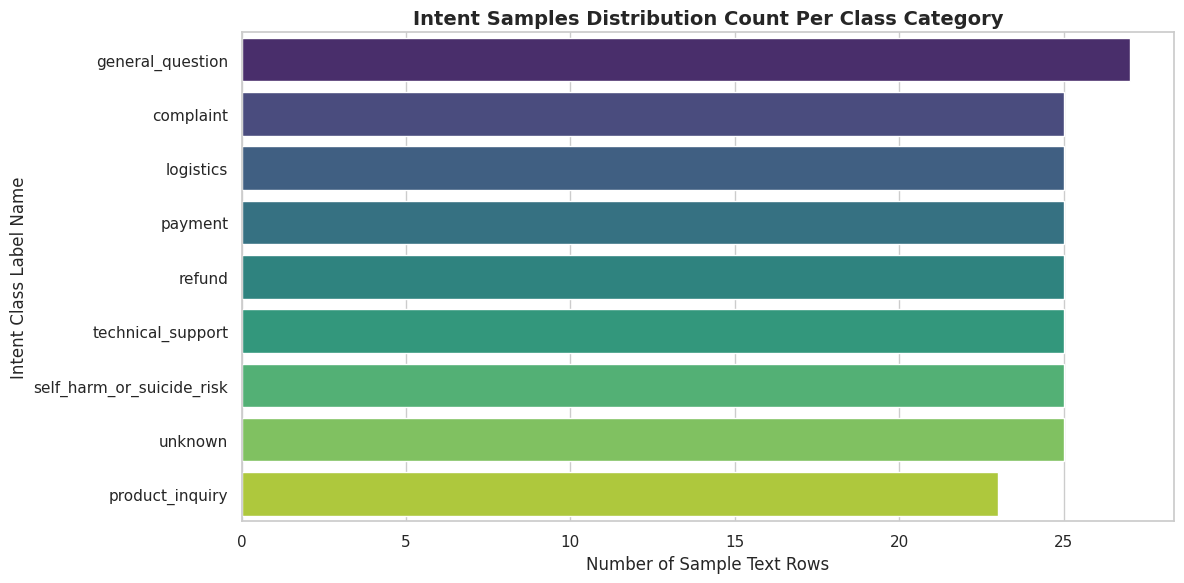

In [6]:
# 1. Calculate class statistics
class_counts = df_clean['label'].value_counts()
class_percentages = df_clean['label'].value_counts(normalize=True) * 100

df_dist = pd.DataFrame({
    'Total Samples': class_counts,
    'Dataset Percentage (%)': class_percentages.round(2)
})

print("=== CURRENT INTENT CLASS DISTRIBUTION ===")
display(df_dist)

# 2. Render distribution bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette="viridis", legend=False)
plt.title('Intent Samples Distribution Count Per Class Category', fontsize=14, weight='bold')
plt.xlabel('Number of Sample Text Rows', fontsize=12)
plt.ylabel('Intent Class Label Name', fontsize=12)
plt.tight_layout()
plt.show()

#Stratified Train, Validation, and Test Split

In [7]:
target_column = "label"

# 1. First split: Isolate the Training partition (70% of total data)
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    stratify=df_clean[target_column]
)

# 2. Second split: Divide the remaining 30% equally into Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df[target_column]
)

print("=== THREE-WAY STRATIFIED DATASPLIT METRICS ===")
print(f" -> 🟢 Train Set Size      : {len(train_df)} rows ({round(len(train_df)/len(df_clean)*100)}%)")
print(f" -> 🟡 Validation Set Size: {len(val_df)} rows ({round(len(val_df)/len(df_clean)*100)}%)")
print(f" -> 🔴 Test Set Size        : {len(test_df)} rows ({round(len(test_df)/len(df_clean)*100)}%)")

# Verify distribution matching
train_dist = train_df[target_column].value_counts(normalize=True).round(3)
val_dist = val_df[target_column].value_counts(normalize=True).round(3)
print("\nTrain class distribution check:\n", train_dist)

=== THREE-WAY STRATIFIED DATASPLIT METRICS ===
 -> 🟢 Train Set Size      : 157 rows (70%)
 -> 🟡 Validation Set Size: 34 rows (15%)
 -> 🔴 Test Set Size        : 34 rows (15%)

Train class distribution check:
 label
general_question             0.121
complaint                    0.115
logistics                    0.115
technical_support            0.115
self_harm_or_suicide_risk    0.108
payment                      0.108
unknown                      0.108
refund                       0.108
product_inquiry              0.102
Name: proportion, dtype: float64


# Training set Augmentation

In [8]:
# Assign execution hardware acceleration
device = 0 if torch.cuda.is_available() else -1

print("Loading text augmentation model...")
mask_filler = pipeline("fill-mask", model="distilbert-base-uncased", device=device)

# --- PRODUCTION TUNING PARAMETERS ---
TARGET_ROWS_PER_CLASS = 1000  # Enforces a perfect final distribution balance
MAX_ATTEMPTS = 50            # Dynamic ceiling limit to avoid infinite loops

# High-risk business action keywords that the model must NEVER mask or replace
INTENT_ANCHOR_WORDS = {
    "refund", "money", "back", "cancel", "return", "reimburse", "payment",
    "invoice", "receipt", "charge", "shipping", "address", "delivery", "arrive",
    "carrier", "broken", "damaged", "defective", "glitch", "crash", "suicide",
    "harm", "crisis", "helpline", "password", "login", "logout", "account"
}

augmented_records = []

# 3. Dynamic Balancing Generation Loop grouped strictly by intent category
print("\nGenerating balanced synthetic variants...")
for label, group in train_df.groupby("label"):
    print(f"Processing intent group: [{label}]")

    # Always keep the original real-world ground-truth rows first
    class_records = group[["text", "label"]].to_dict(orient="records")

    # FIXED: Added the proper .str accessor to the strip function to fix the AttributeError
    existing_texts = set(group["text"].str.lower().str.strip())

    attempts = 0
    # Dynamic balancing guardrail loop
    while len(class_records) < TARGET_ROWS_PER_CLASS and attempts < MAX_ATTEMPTS:
        attempts += 1

        for _, row in group.iterrows():
            if len(class_records) >= TARGET_ROWS_PER_CLASS:
                break

            text = str(row['text'])
            words = text.split()

            if len(words) < 3:
                continue

            # Filter indices to prevent replacing critical anchor keywords
            valid_mask_indices = [
                i for i, word in enumerate(words)
                if word.lower().strip("?,.!") not in INTENT_ANCHOR_WORDS
            ]

            # Fallback if the sentence is completely packed with anchor keywords
            if not valid_mask_indices:
                valid_mask_indices = list(range(len(words)))

            # Pick a safe random index to mask
            mask_idx = random.choice(valid_mask_indices)

            masked_words = words.copy()
            masked_words[mask_idx] = "[MASK]"
            masked_sentence = " ".join(masked_words)

            try:
                # Generate variations
                predictions = mask_filler(masked_sentence, top_k=5)
                if not isinstance(predictions, list):
                    predictions = [predictions]

                for pred in predictions:
                    variant_text = " ".join(pred['sequence'].split())
                    variant_clean = variant_text.lower().strip()

                    # Prevent identical duplicates from eating dataset rows
                    if variant_clean not in existing_texts:
                        class_records.append({"text": variant_text, "label": label})
                        existing_texts.add(variant_clean)

                        if len(class_records) >= TARGET_ROWS_PER_CLASS:
                            break
            except Exception:
                pass

    augmented_records.extend(class_records)

# 4. Compile and verify dataset structure integrity
train_df_augmented = pd.DataFrame(augmented_records)
train_df_augmented.drop_duplicates(subset=['text'], inplace=True)


print("\n🚀 Balanced Expansion Complete!")
print(f"New training set size: {len(train_df_augmented)} rows total.")
print("\nFinal verified distribution counts per intent class:")
print(train_df_augmented['label'].value_counts())


Loading text augmentation model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Generating balanced synthetic variants...
Processing intent group: [complaint]


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processing intent group: [general_question]
Processing intent group: [logistics]
Processing intent group: [payment]
Processing intent group: [product_inquiry]
Processing intent group: [refund]
Processing intent group: [self_harm_or_suicide_risk]
Processing intent group: [technical_support]
Processing intent group: [unknown]

🚀 Balanced Expansion Complete!
New training set size: 5931 rows total.

Final verified distribution counts per intent class:
label
technical_support            816
complaint                    799
general_question             738
self_harm_or_suicide_risk    715
refund                       645
product_inquiry              641
payment                      589
logistics                    501
unknown                      487
Name: count, dtype: int64


In [9]:
# Define your export folder location path layout
EXPORT_DIR = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/"

train_df_augmented[['text', 'label']].to_csv(f"{EXPORT_DIR}train_augmented.csv", index=False)
val_df[['text', 'label']].to_csv(f"{EXPORT_DIR}val.csv", index=False)
test_df[['text', 'label']].to_csv(f"{EXPORT_DIR}test.csv", index=False)

print("🎉 Data processing complete!")
print(f"Saved optimized splits to storage directory: {EXPORT_DIR}")
print("   - train_augmented.csv (training dataset)")
print("   - val.csv            (Unaltered validation reference data)")
print("   - test.csv           (Final holdout tracking validation metrics)")

🎉 Data processing complete!
Saved optimized splits to storage directory: /content/drive/MyDrive/AIE_Project/intent_classification_datasets/
   - train_augmented.csv (training dataset)
   - val.csv            (Unaltered validation reference data)
   - test.csv           (Final holdout tracking validation metrics)


In [10]:
# 1. Define your exact storage location paths
EXPORT_DIR = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/"
train_path = f"{EXPORT_DIR}train_augmented.csv"
val_path = f"{EXPORT_DIR}val.csv"

# 2. Use Hugging Face to load the separate split files directly into a unified object
raw_datasets = load_dataset('csv', data_files={
    'train': train_path,
    'validation': val_path
})


# 3. Dynamically extract the unique text categories for labeling consistency
# We read from the validation set because it preserves your natural, un-duplicated categories
df_val_reference = pd.read_csv(val_path)
unique_labels = sorted(df_val_reference["label"].unique().tolist())

# 4. Print structured metrics to confirm the files match perfectly
print("==========================================================")
print("             DATA SPLIT LOAD REPORT                      ")
print("==========================================================\n")
print(f"✅ Total Unique Classes Loaded: {len(unique_labels)}")
print(f" -> Balanced Training Set Size : {len(raw_datasets['train'])} rows")
print(f" -> Natural Validation Set Size: {len(raw_datasets['validation'])} rows")
print(f"\nDetected Classes: {unique_labels}")


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

             DATA SPLIT LOAD REPORT                      

✅ Total Unique Classes Loaded: 9
 -> Balanced Training Set Size : 5931 rows
 -> Natural Validation Set Size: 34 rows

Detected Classes: ['complaint', 'general_question', 'logistics', 'payment', 'product_inquiry', 'refund', 'self_harm_or_suicide_risk', 'technical_support', 'unknown']


In [11]:
# 1. Base model architecture selection
MODEL_NAME = "distilbert-base-uncased"

# 2. Build explicit mappings from the unique labels list (defined in cell 3)
id2label_clean = {str(idx): label for idx, label in enumerate(unique_labels)}
label2id_clean = {label: idx for idx, label in enumerate(unique_labels)}

# 3. Label Mapping Function to convert string labels into numeric integers
def encode_labels(example):
    # Converts string text label e.g., "refund" to 5
    example["label"] = label2id_clean[example["label"]]
    return example

# Apply label integer conversion to your train and validation sets
encoded_datasets = raw_datasets.map(encode_labels)

# 4. Load the tokenizer matching the core encoder model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # Truncate and pad text strings to ensure uniform input length matrix dimensions
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize the data rows using our integer-mapped dataset
tokenized_datasets_raw = encoded_datasets.map(tokenize_function, batched=True)

# 5. Explicitly remove the raw 'text' string column so PyTorch doesn't try to tensor-ize it
columns_to_remove = [col for col in tokenized_datasets_raw["train"].column_names if col not in ["label", "input_ids", "attention_mask"]]
tokenized_datasets = tokenized_datasets_raw.remove_columns(columns_to_remove)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 6. Instantiate the architecture with explicit dynamic class configurations
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(unique_labels),
    id2label=id2label_clean,
    label2id=label2id_clean
)

# 7. Connect standard metric logging evaluation frameworks
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

print(f"✅ Tokenizer and Model successfully initialized for {len(unique_labels)} classes!")
print(f"Kept features for training tensor conversion: {tokenized_datasets['train'].column_names}")


Map:   0%|          | 0/5931 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

Map:   0%|          | 0/5931 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Tokenizer and Model successfully initialized for 9 classes!
Kept features for training tensor conversion: ['label', 'input_ids', 'attention_mask']


In [13]:
training_args = TrainingArguments(
    output_dir="/content/intent_model",
    learning_rate=1e-5,                  # Fast, stable fine-tuning learning rate
    per_device_train_batch_size=16,       # Scaled batch sizing for T4 GPU acceleration
    per_device_eval_batch_size=16,
    num_train_epochs=20,                  # Balanced iteration count over the larger dataset
    weight_decay=0.1,
    eval_strategy="epoch",               # Evaluate accuracy metrics after each training loop pass
    save_strategy="epoch",
    load_best_model_at_end=True,         # Track and reload optimal state weights automatically
    metric_for_best_model="eval_loss",   # Tracks loss calculation directly
    greater_is_better=False,             # We want the lowest possible validation loss
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Execute model training
trainer.train()

# Permanently persist model weights and configurations cleanly to storage disk
model.save_pretrained("/content/intent_model")
tokenizer.save_pretrained("/content/intent_model")
print("\n🎉 Training Complete! Clean model saved to /content/intent_model")


Epoch,Training Loss,Validation Loss,Accuracy
1,0.001052,0.879537,0.823529
2,0.000382,0.983697,0.794118
3,0.000199,1.072036,0.794118
4,0.000113,1.134480,0.823529


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training Complete! Clean model saved to /content/intent_model


In [14]:
# 1. Run model predictions across the 15% validation split dataset
validation_output = trainer.predict(tokenized_datasets["validation"])

# 2. Extract the predicted class IDs and actual ground-truth label IDs, EXTRACT RAW PROBABILITIES FOR AUC CALCULATIONS
predicted_class_ids = np.argmax(validation_output.predictions, axis=-1)
true_class_ids = validation_output.label_ids
predicted_probabilities = softmax(validation_output.predictions, axis=-1)
# -----------------------------------------------------------

# 3. Compute Multi-Class ROC-AUC metrics via One-vs-Rest (OvR)
# 'macro' evaluates the boundary precision of each intent class with equal weight
# 'weighted' scales the final score according to the underlying text row volumes per class
macro_auc = roc_auc_score(true_class_ids, predicted_probabilities, multi_class='ovr', average='macro')
weighted_auc = roc_auc_score(true_class_ids, predicted_probabilities, multi_class='ovr', average='weighted')

# 4. Print the comprehensive classification matrix & AUC report
print("==========================================================")
print("             FINAL MODEL TRAINING PERFORMANCE REPORT      ")
print("==========================================================\n")

print(f" » Overall Validation Accuracy : {accuracy_score(true_class_ids, predicted_class_ids):.4f}")
print(f" » Macro-Averaged ROC-AUC      : {macro_auc:.4f}  (Evaluates class boundaries equally)")
print(f" » Weighted-Averaged AUC       : {weighted_auc:.4f}  (Adjusts for class data volumes)")
print("\n" + "="*58 + "\n")

print(" Detailed Classification Matrix Report:")
print(classification_report(
    true_class_ids,
    predicted_class_ids,
    target_names=unique_labels,
    digits=4
))


             FINAL MODEL TRAINING PERFORMANCE REPORT      

 » Overall Validation Accuracy : 0.8235
 » Macro-Averaged ROC-AUC      : 0.9603  (Evaluates class boundaries equally)
 » Weighted-Averaged AUC       : 0.9589  (Adjusts for class data volumes)


 Detailed Classification Matrix Report:
                           precision    recall  f1-score   support

                complaint     0.7500    1.0000    0.8571         3
         general_question     0.8000    1.0000    0.8889         4
                logistics     0.5714    1.0000    0.7273         4
                  payment     1.0000    0.7500    0.8571         4
          product_inquiry     1.0000    1.0000    1.0000         3
                   refund     1.0000    0.5000    0.6667         4
self_harm_or_suicide_risk     1.0000    1.0000    1.0000         4
        technical_support     1.0000    0.5000    0.6667         4
                  unknown     0.7500    0.7500    0.7500         4

                 accuracy         

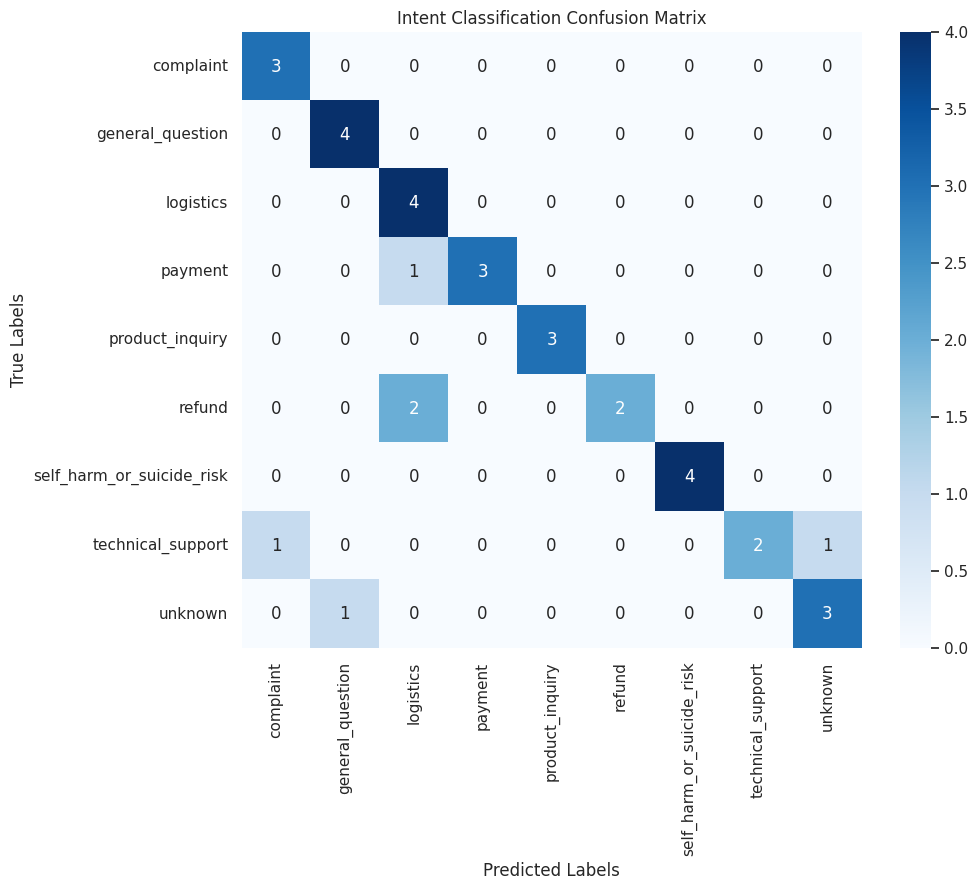

In [15]:
# 1. Gather true labels and model predictions across validation data
predictions = trainer.predict(tokenized_datasets["validation"])
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# 2. Compute matrix configuration layout
cm = confusion_matrix(true_labels, preds)

# 3. Plot chart map
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels, cmap="Blues")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Intent Classification Confusion Matrix')
plt.show()
